In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import ast
import re

In [2]:
def modify(results_df):
    
    results_combined = results_df.copy()[['prediction','ground_truth', 'ground_truth_text', 'ID', 'generated_text']]
    results_combined['correctness'] = results_combined['prediction'] == results_combined['ground_truth']
    
    return results_combined

In [3]:
# def add_clinical_diag(row):
#     row['ID'] = row['NACCID']
#     if (row['NACCALZP'] in [1, 2]) and (row['NACCLBDP'] in [1, 2]) and (
#         row['FTLDMOIF'] in [1, 2] or row['FTLDNOIF'] in [1, 2] or row['FTDIF'] in [1, 2]
#     ):
#         row["prediction"] = 'G'
#     elif (row['NACCLBDP'] in [1, 2]) and (
#         row['FTLDMOIF'] in [1, 2] or row['FTLDNOIF'] in [1, 2] or row['FTDIF'] in [1, 2]
#     ):
#         row["prediction"] = 'F'
#     elif (row['NACCALZP'] in [1, 2]) and (
#         row['FTLDMOIF'] in [1, 2] or row['FTLDNOIF'] in [1, 2] or row['FTDIF'] in [1, 2]
#     ):
#         row["prediction"] = 'E'
#     elif (row['NACCALZP'] in [1, 2]) and (row['NACCLBDP'] in [1, 2]):
#         row["prediction"] = 'D'
#     elif row['FTLDMOIF'] in [1, 2] or row['FTLDNOIF'] in [1, 2] or row['FTDIF'] in [1, 2]:
#         row["prediction"] = 'C'
#     elif row['NACCLBDP'] in [1, 2]:
#         row["prediction"] = 'B'
#     elif row['NACCALZP'] in [1, 2]:
#         row["prediction"] = 'A'
#     else:
#         row["prediction"] = 'H'
#     return row

In [4]:
# test_data = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/testing_data_grpo/test_summary.csv")
# test_data_summary = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/testing_data_grpo/with_summary/test_np.csv")

In [5]:
# # qwen25_3b_path = "../llm_answer_extractor/extracted_results/ETPR/qwen25_3b_ETPR.csv"
# # qwen25_7b_path = "../llm_answer_extractor/extracted_results/ETPR/qwen25_7b_ETPR.csv"
# # qwen25_14b_path = "../llm_answer_extractor/extracted_results/ETPR/qwen25_14b_ETPR.csv"
# # qwen25_3b_drgrpo_filtered_path = "../llm_answer_extractor/extracted_results/ETPR/qwen25_3b_drgrpo_filtered_ETPR.csv"


# # qwen25_3b_path = "../llm_answer_extractor/extracted_results/Neuropath/qwen25_3b_Neuropath.csv"
# # qwen25_7b_path = "../llm_answer_extractor/extracted_results/Neuropath/qwen25_7b_Neuropath.csv"
# # qwen25_14b_path = "../llm_answer_extractor/extracted_results/Neuropath/qwen25_14b_Neuropath.csv"
# # qwen25_3b_drgrpo_filtered_path = "../llm_answer_extractor/extracted_results/Neuropath/qwen25_3b_drgrpo_filtered_Neuropath.csv"

# # eval_type = "Neuropath"
# # eval_type = "ETPR"
# eval_type = "MCI"
# # eval_type = "COGSTAT"
# qwen25_3B_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_{eval_type}.csv"
# qwen25_7B_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_7B_{eval_type}.csv"
# qwen25_14B_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_14B_{eval_type}.csv"
# qwen25_3B_drgrpo_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_gp16_{eval_type}.csv"

# # qwen25_3b_drgrpo_filtered_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3b_drgrpo_filtered_{eval_type}.csv"
# # # qwen25_3b_drgrpo_filtered_no_KL_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3b_drgrpo_filtered_no_KL_{eval_type}.csv"
# # # qwen25_3b_drgrpo_filtered_oversample_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3b_drgrpo_filtered_oversample_{eval_type}.csv"
# # # qwen25_3b_drgrpo_filtered_oversample_3x_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_filtered_oversample_3x_{eval_type}.csv"
# # # qwen25_3B_drgrpo_filtered_2_grad_updates_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_filtered_oversample_3x_{eval_type}.csv"
# # # qwen25_3B_sft_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_sft_{eval_type}.csv"
# # qwen25_3B_drgrpo_filtered_option_shuffling_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_filtered_option_shuffling_{eval_type}.csv"
# # qwen25_3B_sft_with_eval_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_sft_with_eval_{eval_type}.csv"
# # # qwen25_3B_drgrpo_filtered_option_shuffling_gp_16_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_filtered_option_shuffling_gp_16_{eval_type}.csv"
# # qwen25_3B_drgrpo_filtered_option_shuffling_gp_32_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_filtered_option_shuffling_gp_32_{eval_type}.csv"

In [6]:
# # eval_type = "Neuropath"
# # eval_type = "ETPR"
# eval_type = "MCI"
# # eval_type = "COGSTAT"
# qwen25_3B_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_{eval_type}.csv"
# qwen25_7B_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_7B_{eval_type}.csv"
# qwen25_14B_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_14B_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_gp16_{eval_type}.csv"
# qwen25_3B_drgrpo_gp32_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_gp32_{eval_type}.csv"
# qwen25_3B_sft_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_sft_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_stage_wise_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_gp16_stage_wise_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_stage_wise_rewards_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_gp16_stage_wise_rewards_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_stages234_epoch2_path = f"../llm_answer_extractor/extracted_results/{eval_type}/qwen25_3B_drgrpo_gp16_stages234_epoch2_{eval_type}.csv"


In [8]:
eval_type = "Neuropath"
# eval_type = "ETPR"
# eval_type = "MCI"
# eval_type = "COGSTAT"
qwen25_3B_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_{eval_type}.csv"
qwen25_3B_old_prompt_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_old_prompt_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_all_train_sub_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_all_train_sub_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_all_train_sub_old_prompt_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_all_train_sub_old_prompt_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_all_train_sub_no_KL_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_all_train_sub_no_KL_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_train_filtered_sub_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_train_filtered_sub_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_train_filtered_sub_no_KL_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_train_filtered_sub_no_KL_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_stage_wise_sub_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_stage_wise_sub_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_stage_wise_sub_no_KL_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_stage_wise_sub_no_KL_{eval_type}.csv"


In [9]:
# qwen25_3B = pd.read_csv(qwen25_3B_path)
# qwen25_7B = pd.read_csv(qwen25_7B_path)
# qwen25_14B = pd.read_csv(qwen25_14B_path)
# qwen25_3B_drgrpo_gp16 = pd.read_csv(qwen25_3B_drgrpo_gp16_path)
# qwen25_3B_drgrpo_gp32 = pd.read_csv(qwen25_3B_drgrpo_gp32_path)
# qwen25_3B_sft = pd.read_csv(qwen25_3B_sft_path)
# qwen25_3B_drgrpo_gp16_stage_wise = pd.read_csv(qwen25_3B_drgrpo_gp16_stage_wise_path)
# qwen25_3B_drgrpo_gp16_stage_wise_rewards = pd.read_csv(qwen25_3B_drgrpo_gp16_stage_wise_rewards_path)
# qwen25_3B_drgrpo_gp16_stages234_epoch2 = pd.read_csv(qwen25_3B_drgrpo_gp16_stages234_epoch2_path)

qwen25_3B = pd.read_csv(qwen25_3B_path)
qwen25_3B_old_prompt = pd.read_csv(qwen25_3B_old_prompt_path)
qwen25_3B_drgrpo_gp16_all_train_sub = pd.read_csv(qwen25_3B_drgrpo_gp16_all_train_sub_path)
qwen25_3B_drgrpo_gp16_all_train_sub_old_prompt = pd.read_csv(qwen25_3B_drgrpo_gp16_all_train_sub_old_prompt_path)
qwen25_3B_drgrpo_gp16_all_train_sub_no_KL = pd.read_csv(qwen25_3B_drgrpo_gp16_all_train_sub_no_KL_path)
qwen25_3B_drgrpo_gp16_train_filtered_sub = pd.read_csv(qwen25_3B_drgrpo_gp16_train_filtered_sub_path)
qwen25_3B_drgrpo_gp16_train_filtered_sub_no_KL = pd.read_csv(qwen25_3B_drgrpo_gp16_train_filtered_sub_no_KL_path)
qwen25_3B_drgrpo_gp16_stage_wise_sub = pd.read_csv(qwen25_3B_drgrpo_gp16_stage_wise_sub_path)
qwen25_3B_drgrpo_gp16_stage_wise_sub_no_KL = pd.read_csv(qwen25_3B_drgrpo_gp16_stage_wise_sub_no_KL_path)

In [10]:
cnt = []
max_cnt = 0
for i, row in qwen25_3B_drgrpo_gp16_stage_wise_sub_no_KL.iterrows():
    all_matches = re.findall(r'\\boxed{([A-Z])(?:\.\s*[^}]*)?}', row['generated_text'])
    if len(all_matches) > 1:
        max_cnt = max(max_cnt, len(all_matches))
        cnt += [(i, row['generated_text'])]
        
max_cnt

4

In [11]:
len(cnt)

41

In [12]:
print(cnt[2][1])

Let's analyze the clinical information provided step by step to determine the most likely pathologies underlying the patient's cognitive symptoms:

1. **Subject Evaluation:**
   - Age: 94 years
   - Racial/ethnic background: White
   - Language: English
   - Education: 20 years
   - Living situation: Married, living with spouse in a private residence
   - Handedness: Right-handed
   - Medications: Includes anticoagulants, antiplatelet agents, ACE inhibitors, beta-blockers, lipid-lowering agents, antidepressants, etc.
   - Family History: Cognitive impairment in mother, no reported problems in father (implying a possible family history of Alzheimer's or another similar disease in cLN).
   - Care Support: Requires assistance with instrumental activities of daily living.
   - Imaging findings: FDG-PET consistent with Alzheimer’s disease and hippocampal atrophy. No evidence of other neurodegenerative diseases typically noted.
   - Symptoms: Delusions (mild severity), moderate agitation/ang

In [13]:
# models = {
#     "qwen25_3B": qwen25_3B,
#     "qwen25_7B": qwen25_7B,
#     "qwen25_14B": qwen25_14B,
#     "qwen25_3B_sft": qwen25_3B_sft,
#     "qwen25_3B_drgrpo_gp16": qwen25_3B_drgrpo_gp16,
#     "qwen25_3B_drgrpo_gp32": qwen25_3B_drgrpo_gp32,
#     "qwen25_3B_drgrpo_gp16_stage_wise": qwen25_3B_drgrpo_gp16_stage_wise,
#     "qwen25_3B_drgrpo_gp16_stage_wise_rewards": qwen25_3B_drgrpo_gp16_stage_wise_rewards,
#     # "qwen25_3B_drgrpo_gp16_stages234_epoch2": qwen25_3B_drgrpo_gp16_stages234_epoch2,
# }

models = {
    "qwen25_3B": qwen25_3B,
    "qwen25_3B_old_prompt": qwen25_3B_old_prompt,
    "qwen25_3B_drgrpo_gp16_all_train_sub": qwen25_3B_drgrpo_gp16_all_train_sub,
    "qwen25_3B_drgrpo_gp16_all_train_sub_old_prompt": qwen25_3B_drgrpo_gp16_all_train_sub_old_prompt,
    "qwen25_3B_drgrpo_gp16_all_train_sub_no_KL": qwen25_3B_drgrpo_gp16_all_train_sub_no_KL,
    "qwen25_3B_drgrpo_gp16_train_filtered_sub": qwen25_3B_drgrpo_gp16_train_filtered_sub,
    "qwen25_3B_drgrpo_gp16_train_filtered_sub_no_KL": qwen25_3B_drgrpo_gp16_train_filtered_sub_no_KL,
    "qwen25_3B_drgrpo_gp16_stage_wise_sub": qwen25_3B_drgrpo_gp16_stage_wise_sub,
    "qwen25_3B_drgrpo_gp16_stage_wise_sub_no_KL": qwen25_3B_drgrpo_gp16_stage_wise_sub_no_KL,
}

# test_data_subset = test_data[test_data['NACCID'].isin(models['qwen25_3b']['ID'])].reset_index(drop=True)
# test_data_summary_subset = test_data_summary[test_data_summary['ID'].isin(models['qwen25_3b']['ID'])].reset_index(drop=True)
# test_data_subset = test_data_subset[['NACCID', 'NACCALZP', 'NACCLBDP', 'FTLDMOIF', 'FTLDNOIF', 'FTDIF']]
# test_data_subset = test_data_subset.apply(add_clinical_diag, axis=1)
# test_data_subset.drop(['NACCID'], axis=1, inplace=True)
# test_data_merged = test_data_summary_subset.merge(test_data_subset, on=['ID'])
# models['clinician'] = test_data_merged

modified_models = {name: modify(df) for name, df in models.items()}

In [14]:
gt_dict = {
    "Neuropath": [
        "Alzheimer's disease pathology (AD) only",
        "Lewy body pathology (LBD) only",
        "Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD) only",
        "Alzheimer's disease pathology (AD) and Lewy body pathology (LBD)",
        "Alzheimer's disease pathology (AD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)",
        "Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)",
        "Alzheimer's disease pathology (AD), Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)",
        "No listed option is correct",
    ],
    "ETPR": [
        "Alzheimer's disease (AD)",
        "Lewy body disease (LBD)",
        "Frontotemporal lobar degeneration and its variants, including primary progressive aphasia, corticobasal degeneration and progressive supranuclear palsy, and with or without amyotrophic lateral sclerosis (FTLD)",
        "Vascular brain injury or vascular dementia including stroke (VD)",
        "Systemic and environmental factors including infectious diseases (HIV included), metabolic, substance abuse / alcohol, medications, systemic disease and delirium (SEF)",
        "Psychiatric conditions including schizophrenia, depression, bipolar disorder, anxiety and posttraumatic stress disorder (PSY)",
        "Other (Multiple system atrophy, Essential tremor, Down syndrome, Huntington's disease, Prion disease, Traumatic brain injury, Normal-pressure hydrocephalus, Epilepsy, CNS neoplasm, etc)",
        "Not applicable (no cognitive impairment)",
    ],
    "MCI": [
        "Amnestic MCI",
        "Non-amnestic MCI",
        "Not applicable (no diagnosis of MCI)",
    ],
    "COGSTAT": [
        "Normal Cognition (NC)",
        "Mild Cognitive Impairment (MCI)",
        "Dementia (DE)"
    ]
}

In [15]:
# df = modified_models['qwen25_3B_drgrpo_gp16_stage_wise_sub']
# # df = modified_models['qwen25_3B']
# df_gt = df[df['ground_truth_text'] == gt_dict[eval_type][0]].reset_index(drop=True)
# df_gt.index = df_gt.groupby('ID', sort=False).ngroup()
# df_gt = df_gt.reset_index(names=['problem']).reset_index(drop=True)

In [16]:
# print(df_gt.iloc[-10]['correctness'])
# print(models['qwen25_3B_drgrpo_gp16_stages234_epoch2'][models['qwen25_3B_drgrpo_gp16_stages234_epoch2']['ID'] == df_gt.iloc[-10]['ID']].iloc[0]['prediction'])
# print(models['qwen25_3B_drgrpo_gp16_stages234_epoch2'][models['qwen25_3B_drgrpo_gp16_stages234_epoch2']['ID'] == df_gt.iloc[-10]['ID']].iloc[0]['generated_text'])
# ast.literal_eval(models['qwen25_3B_drgrpo_gp16_stages234_epoch2'][models['qwen25_3B_drgrpo_gp16_stages234_epoch2']['ID'] == df_gt.iloc[-10]['ID']].iloc[0]['problem'])

In [17]:
def pass_at_k(df, n, k=1): 
    """ 
    :param n: total number of samples 
    :param c: number of correct samples 
    :param k: k in pass@$k$ """
    # print(n)
    cs = df.groupby('problem').sum('correctness')
    vals = []
    for i, row in cs.iterrows():
        c = row['correctness']
        # print(n,c,k)
        if n - c < k: vals.append(1.0)
        else: vals.append(1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1)))
         
    # print(vals)
    return np.mean(vals)

def get_passat1(df):
    return df.groupby('problem').mean('correctness')[['correctness']].mean().iloc[0]

def get_consatk(df, n):
    return (
        df.groupby('problem')['prediction']
        .apply(lambda x: x.mode()[0]) == 
        df[['problem', 'ground_truth']].drop_duplicates('problem', keep='first')['ground_truth'].reset_index(drop=True)
    ).sum() / n


In [18]:
def combine_results_by_ground_truth(results_dict, k):
    """
    Like combine_results, but computes pass@1 and cons@k separately for each ground_truth.
    Returns a DataFrame with columns: ['ground_truth', 'metric', 'model', 'score']
    """
    all_records = []

    # Iterate over each model and its corresponding DataFrame in the results dictionary
    for model_name, df in results_dict.items():
        # For each unique ground truth label in the DataFrame
        for gt in df['ground_truth_text'].unique():
            # Filter the DataFrame for the current ground truth
            df_gt = df[df['ground_truth_text'] == gt].reset_index(drop=True)
            # Assign a group number to each unique problem (by 'ID')
            df_gt.index = df_gt.groupby('ID', sort=False).ngroup()
            # Reset index and add a 'problem' column for grouping
            df_gt = df_gt.reset_index(names=['problem']).reset_index(drop=True)
            # print(df_gt)  # For debugging: show the processed DataFrame

            # Number of unique problems
            n = len(df_gt['ID'].unique())
            # Number of attempts per problem (assumes equal number for all)
            p = len(df_gt) // n
            # print(gt, n, p)  # For debugging: show current ground truth, n, and p

            # Compute pass@k score for this ground truth and model
            pass_score = pass_at_k(df_gt, p, k)
            # pass_score = get_passat1(df_gt)  # Alternative: use pass@1 function

            # Compute consistency@k score for this ground truth and model
            cons_score = get_consatk(df_gt, n)

            # Append pass@1 result to the records list
            all_records.append({
                'ground_truth': gt,
                'metric': 'pass@1',
                'model': model_name,
                'score': pass_score
            })
            # Optionally, append cons@k result (currently commented out)
            # all_records.append({
            #     'ground_truth': gt,
            #     'metric': 'cons@k',
            #     'model': model_name,
            #     'score': cons_score
            # })

    # Convert the list of records to a DataFrame and return
    return pd.DataFrame(all_records)


In [22]:
def plot_model_comparison_by_gt(df_long, k=1, out_path="np_by_gt.pdf"):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Exclude clinician for barplot, but keep for reference line
    df_no_clinician = df_long[df_long["model"] != "clinician"]

    # Color palette: key models (not drgrpo) in red, others in blue
    models = df_no_clinician["model"].unique()
    key_models = [m for m in models if "drgrpo" not in m.lower()]
    other_models = [m for m in models if m not in key_models]
    palette = dict(zip(key_models, sns.color_palette("Reds", len(key_models))))
    palette.update(zip(other_models, sns.color_palette("Blues", len(other_models))))

    # Set ground truth order
    sorted_gt = gt_dict[eval_type]
    df_no_clinician["ground_truth"] = pd.Categorical(df_no_clinician["ground_truth"], categories=sorted_gt, ordered=True)

    # Plot
    g = sns.catplot(
        data=df_no_clinician,
        kind="bar",
        x="metric", y="score", hue="model",
        col="ground_truth", col_wrap=1,
        palette=palette,
        height=4.5, aspect=1.3
    )

    # Add clinician reference line if present
    clinician_df = df_long[df_long["model"] == "clinician"]
    if not clinician_df.empty:
        for ax, col_name in zip(g.axes.flatten(), g.col_names):
            val = clinician_df[
                (clinician_df["ground_truth"] == col_name) &
                (clinician_df["metric"] == "pass@1")
            ]["score"]
            if not val.empty:
                ax.axhline(val.values[0], linestyle='--', color='red', alpha=0.7, label="Clinician")

    # Add bar labels
    for ax in g.axes.flatten():
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

    g.set_titles("Ground Truth: {col_name}")
    g.set_axis_labels("Metric", "Score")
    g.set(ylim=(0, 1.05))

    # Handle legend: put on each subplot, remove shared
    handles, labels = g.axes[-1].get_legend_handles_labels()
    if g._legend: g._legend.remove()
    for ax in g.axes.flatten():
        ax.legend(handles, labels, title='Model', frameon=False, loc='upper left', fontsize='small', title_fontsize='small')

    plt.tight_layout()
    plt.savefig(f"../llm_answer_extractor/outputs_sub/subgroups/{eval_type.lower()}.pdf", format='pdf', bbox_inches='tight', dpi=300)
    # plt.show()


In [23]:
# def plot_model_comparison_by_gt(df_long, k=1, out_path="np_by_gt.pdf"):
#     import matplotlib.pyplot as plt
#     import seaborn as sns


#     # Separate clinician and others
#     df_no_clinician = df_long[df_long["model"] != "clinician"]
#     # df_no_clinician = df_long

#     # Sort models by average pass@1
#     # sorted_models = (
#     #     df_no_clinician[df_no_clinician['metric'] == 'pass@1']
#     #     .groupby('model')['score'].mean()
#     #     .sort_values()
#     #     .index.tolist()
#     # )

#     # Color palette
#     key_models = [m for m in df_no_clinician["model"].unique() if "drgrpo" not in m.lower()]
#     other_models = [m for m in df_no_clinician["model"].unique() if m not in key_models]

#     palette = {}
#     red_shades = sns.color_palette("Reds", len(key_models))
#     blue_shades = sns.color_palette("Blues", len(other_models))
#     for m, c in zip(key_models, red_shades): palette[m] = c
#     for m, c in zip(other_models, blue_shades): palette[m] = c

#     # df_no_clinician["model"] = pd.Categorical(df_no_clinician["model"], categories=sorted_models, ordered=True)
#     # sorted_gt = sorted(df_no_clinician["ground_truth"].unique())
#     sorted_gt = gt_dict[eval_type]
#     df_no_clinician["ground_truth"] = pd.Categorical(df_no_clinician["ground_truth"], categories=sorted_gt, ordered=True)


#     # Plot
#     g = sns.catplot(
#         data=df_no_clinician,
#         kind="bar",
#         x="metric", y="score", hue="model",
#         col="ground_truth", col_wrap=1,
#         palette=palette,
#         height=4.5, aspect=1.3
#     )

#     # Add clinician lines
#     clinician_df = df_long[df_long["model"] == "clinician"]
#     if len(clinician_df) != 0:
#         for ax, col_name in zip(g.axes.flatten(), g.col_names):
#             for metric in ['pass@1']: #, 'cons@k']:
#                 val = clinician_df[
#                     (clinician_df["ground_truth"] == col_name) &
#                     (clinician_df["metric"] == metric)
#                 ]["score"]
#                 if not val.empty:
#                     ax.axhline(val.values[0], linestyle='--', color='red', alpha=0.7, label="Clinician")
    
#     for ax, col_name in zip(g.axes.flatten(), g.col_names):
#         for container in ax.containers:
#             ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

#     g.set_titles("Ground Truth: {col_name}")
#     g.set_axis_labels("Metric", "Score")
#     g.set(ylim=(0, 1.05))
#     # g.add_legend(title='Model', bbox_to_anchor=(1, 0.8), frameon=False)
#     # Remove the shared legend
#     # Get legend handles/labels from the main figure BEFORE removing it
#     handles, labels = g.axes[-1].get_legend_handles_labels()

#     # Remove the shared legend
#     g._legend.remove()

#     # Add legends to each subplot
#     for ax in g.axes.flatten():
#         ax.legend(handles, labels, title='Model', frameon=False, loc='upper left', fontsize='small', title_fontsize='small')



#     plt.tight_layout()
#     plt.savefig(f"../llm_answer_extractor/outputs/subgroups/{eval_type.lower()}.pdf", format='pdf', bbox_inches='tight', dpi=300)
#     # plt.show()


In [24]:
# print(ast.literal_eval(models['qwen25_3b'].iloc[0]['problem'])['options'])

In [25]:
df_long = combine_results_by_ground_truth(modified_models, k=1)

In [26]:
df_long

,ground_truth,metric,model,score
0,Alzheimer's disease pathology (AD) and Frontot...,pass@1,qwen25_3B,0.293269
1,Alzheimer's disease pathology (AD) and Lewy bo...,pass@1,qwen25_3B,0.268811
2,Alzheimer's disease pathology (AD) only,pass@1,qwen25_3B,0.274457
3,No listed option is correct,pass@1,qwen25_3B,0.049603
4,Frontotemporal Lobar Degeneration with tau pat...,pass@1,qwen25_3B,0.129375
...,...,...,...,...
67,No listed option is correct,pass@1,qwen25_3B_drgrpo_gp16_stage_wise_sub_no_KL,0.098214
68,Frontotemporal Lobar Degeneration with tau pat...,pass@1,qwen25_3B_drgrpo_gp16_stage_wise_sub_no_KL,0.116875
69,Lewy body pathology (LBD) only,pass@1,qwen25_3B_drgrpo_gp16_stage_wise_sub_no_KL,0.047414
70,"Alzheimer's disease pathology (AD), Lewy body ...",pass@1,qwen25_3B_drgrpo_gp16_stage_wise_sub_no_KL,0.018229


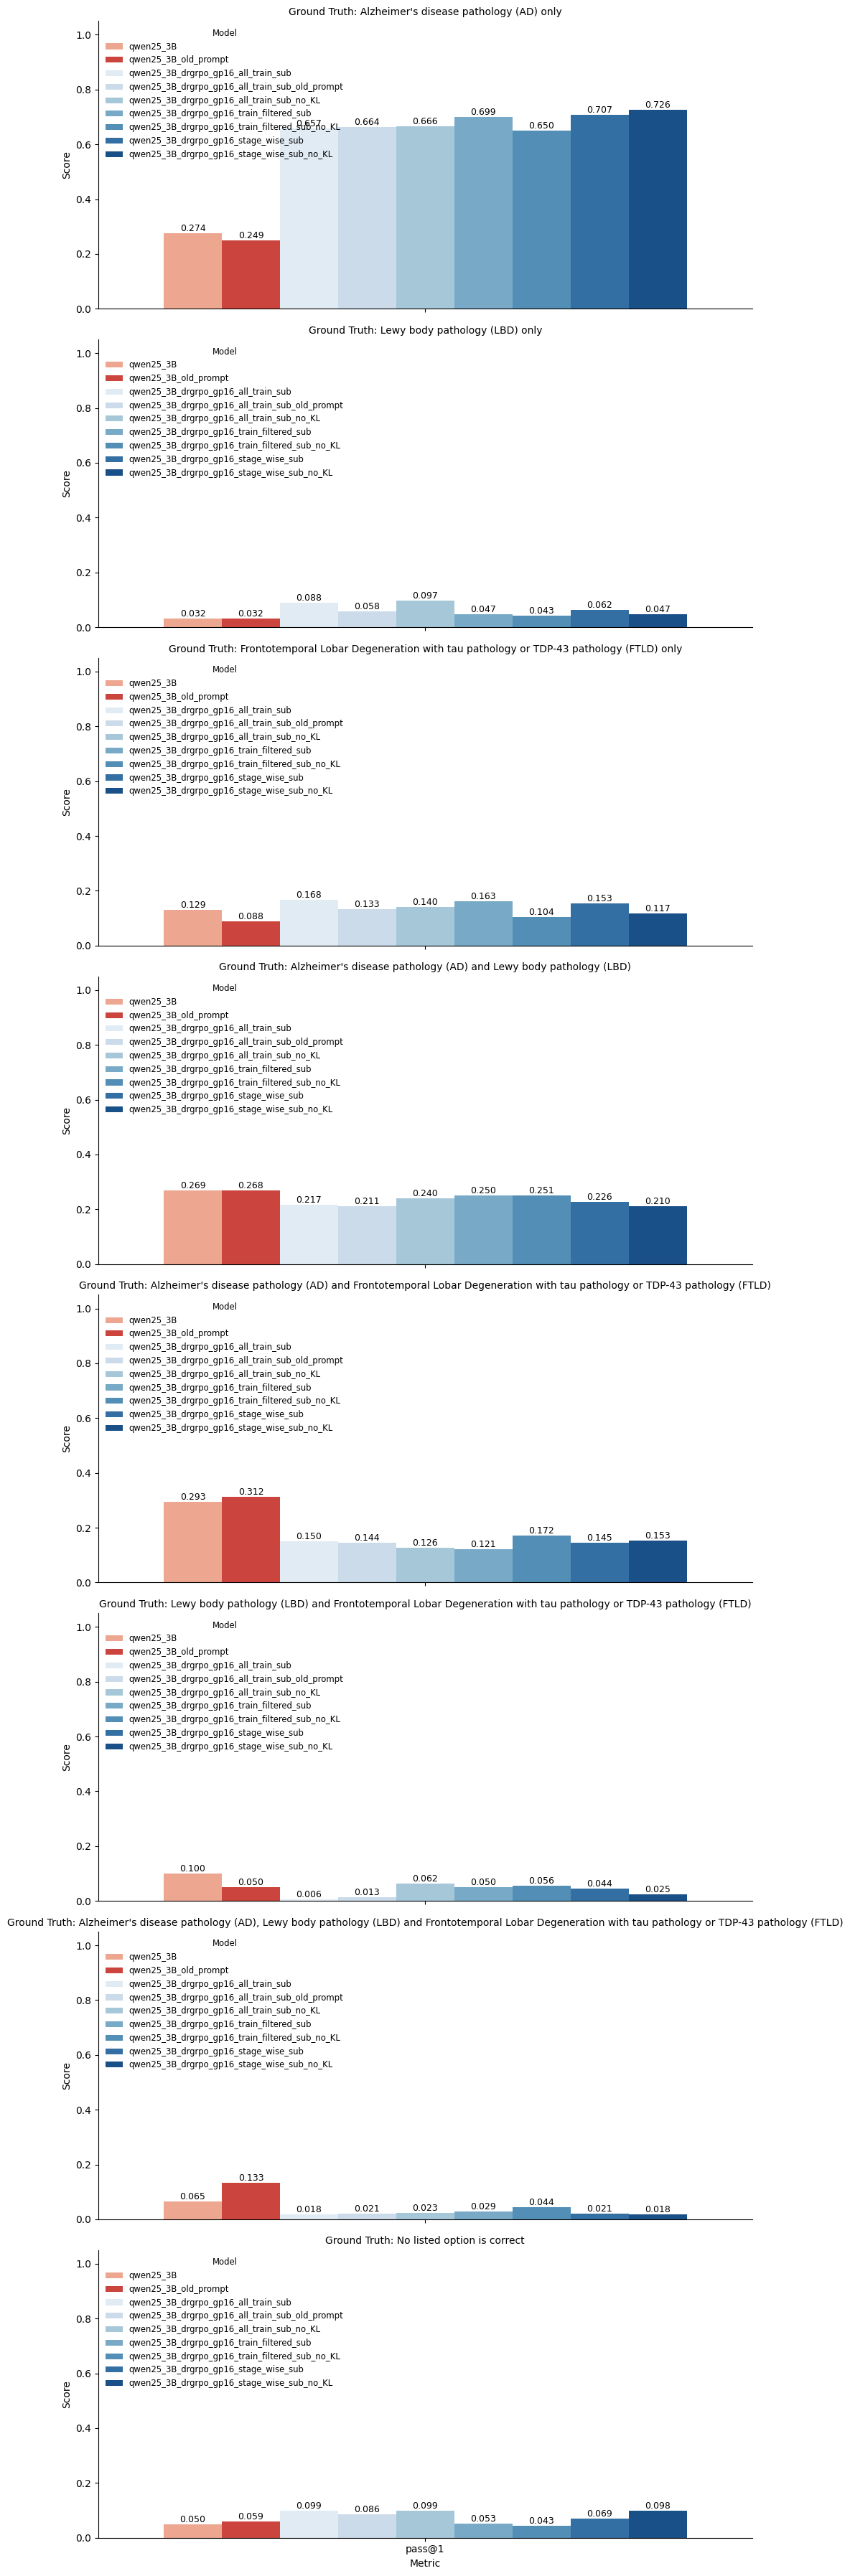

In [27]:
plot_model_comparison_by_gt(df_long, k=1)

In [19]:
df = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/training_data_grpo/subset/stage_wise_sub.csv")

In [22]:
df[df['STAGE'] == 0]['Q_TYPE'].value_counts()

Q_TYPE
Cognitive status    617
Primary etiology    236
Amyloid PET          61
MCI subtype          57
Amyloid CSF          18
Neuropath             6
DATSCAN               5
Name: count, dtype: int64

In [29]:
df[(df['Q_TYPE'] == "MCI subtype") & (df['STAGE'] == 3)]['ground_truth_text'].value_counts()

ground_truth_text
Not applicable (no diagnosis of MCI)    95
Amnestic MCI                            53
Non-amnestic MCI                        13
Name: count, dtype: int64